<a href="https://colab.research.google.com/github/PranshuRanjan10/Capstone_proj_249/blob/main/Pranshu_Ranjan_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Loading the Dataset and Basic Statistical Analysis

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/PhDPublications.csv"
df = pd.read_csv(url)

print("--- Dataset Preview ---")
display(df.head())
print(f"\nShape: {df.shape}")
print("\n--- Basic Statistics ---")
display(df.describe(include='all'))

--- Dataset Preview ---


,rownames,articles,gender,married,kids,prestige,mentor
0,1,0,male,yes,0,2.52,7
1,2,0,female,no,0,2.05,6
2,3,0,female,no,0,3.75,6
3,4,0,male,yes,1,1.18,3
4,5,0,female,no,0,3.75,26



Shape: (915, 7)

--- Basic Statistics ---


,rownames,articles,gender,married,kids,prestige,mentor
count,915.000000,915.000000,915,915,915.000000,915.000000,915.000000
unique,NaN,NaN,2,2,NaN,NaN,NaN
top,NaN,NaN,male,yes,NaN,NaN,NaN
freq,NaN,NaN,494,606,NaN,NaN,NaN
mean,458.000000,1.692896,NaN,NaN,0.495082,3.103109,8.767213
std,264.282046,1.926069,NaN,NaN,0.764880,0.984249,9.483916
min,1.000000,0.000000,NaN,NaN,0.000000,0.755000,0.000000
25%,229.500000,0.000000,NaN,NaN,0.000000,2.260000,3.000000
50%,458.000000,1.000000,NaN,NaN,0.000000,3.150000,6.000000
75%,686.500000,2.000000,NaN,NaN,1.000000,3.920000,12.000000


### 2. Handling Missing Data

In [4]:
print("Missing values before:")
print(df.isnull().sum())

for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(exclude=np.number).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after handling:")
print(df.isnull().sum())

Missing values before:
rownames    0
articles    0
gender      0
married     0
kids        0
prestige    0
mentor      0
dtype: int64

Missing values after handling:
rownames    0
articles    0
gender      0
married     0
kids        0
prestige    0
mentor      0
dtype: int64


### 3. Data Cleaning

In [5]:
duplicate_count = df.duplicated().sum()
df.drop_duplicates(inplace=True)

df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print(f"Removed {duplicate_count} duplicates.")
print("Cleaned columns:", df.columns.tolist())

Removed 0 duplicates.
Cleaned columns: ['rownames', 'articles', 'gender', 'married', 'kids', 'prestige', 'mentor']


### 4. Data Transformation

In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    min_val = df[col].min()
    max_val = df[col].max()
    if max_val != min_val:
        df[col] = (df[col] - min_val) / (max_val - min_val)

print("Data transformation (Min-Max scaling) applied to numeric columns.")
display(df.head())

Data transformation (Min-Max scaling) applied to numeric columns.


,rownames,articles,gender,married,kids,prestige,mentor
0,0.000000,0.0,male,yes,0.000000,0.456662,0.090909
1,0.001094,0.0,female,no,0.000000,0.335058,0.077922
2,0.002188,0.0,female,no,0.000000,0.774903,0.077922
3,0.003282,0.0,male,yes,0.333333,0.109961,0.038961
4,0.004376,0.0,female,no,0.000000,0.774903,0.337662


### 5. Univariate Analysis

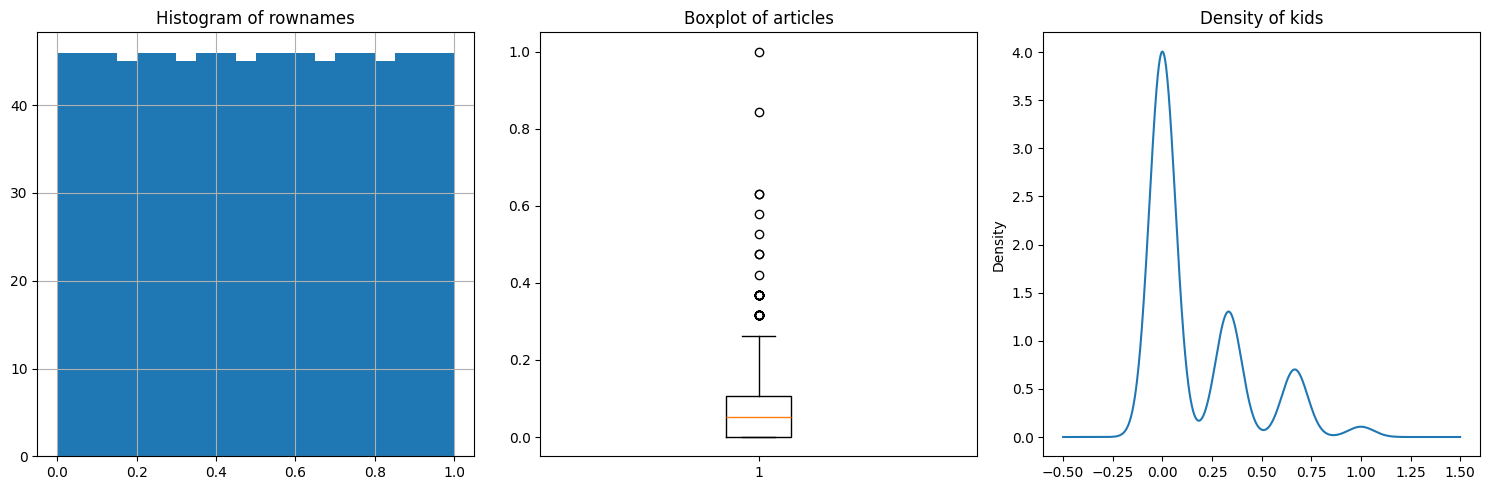

In [7]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
df[numeric_cols[0]].hist(bins=20)
plt.title(f"Histogram of {numeric_cols[0]}")

plt.subplot(1, 3, 2)
plt.boxplot(df[numeric_cols[1]])
plt.title(f"Boxplot of {numeric_cols[1]}")

plt.subplot(1, 3, 3)
df[numeric_cols[2]].plot(kind='density')
plt.title(f"Density of {numeric_cols[2]}")

plt.tight_layout()
plt.show()

### 6. Bivariate Analysis

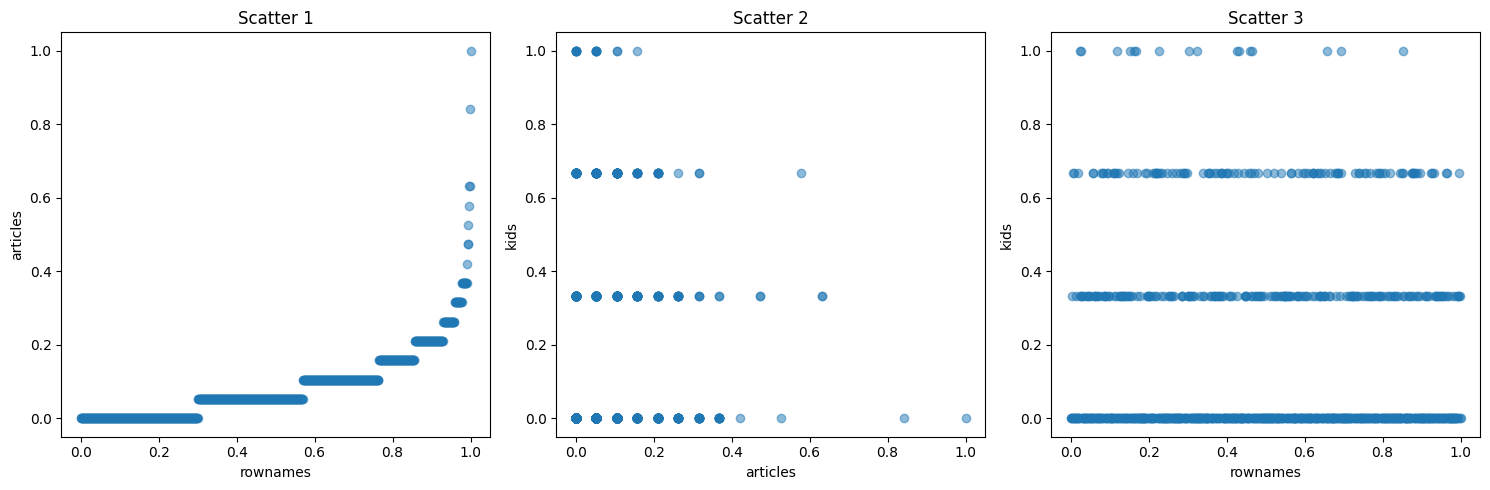

In [8]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(df[numeric_cols[0]], df[numeric_cols[1]], alpha=0.5)
plt.xlabel(numeric_cols[0]); plt.ylabel(numeric_cols[1])
plt.title("Scatter 1")

plt.subplot(1, 3, 2)
plt.scatter(df[numeric_cols[1]], df[numeric_cols[2]], alpha=0.5)
plt.xlabel(numeric_cols[1]); plt.ylabel(numeric_cols[2])
plt.title("Scatter 2")

plt.subplot(1, 3, 3)
plt.scatter(df[numeric_cols[0]], df[numeric_cols[2]], alpha=0.5)
plt.xlabel(numeric_cols[0]); plt.ylabel(numeric_cols[2])
plt.title("Scatter 3")

plt.tight_layout()
plt.show()

### 7. Multivariate Analysis

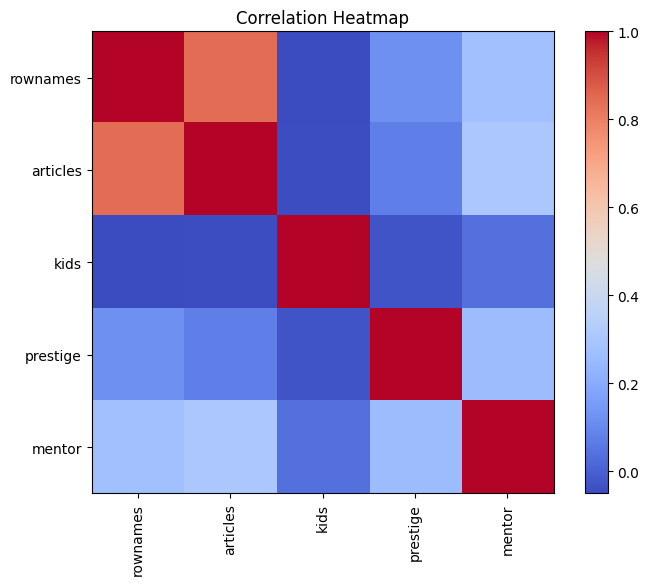

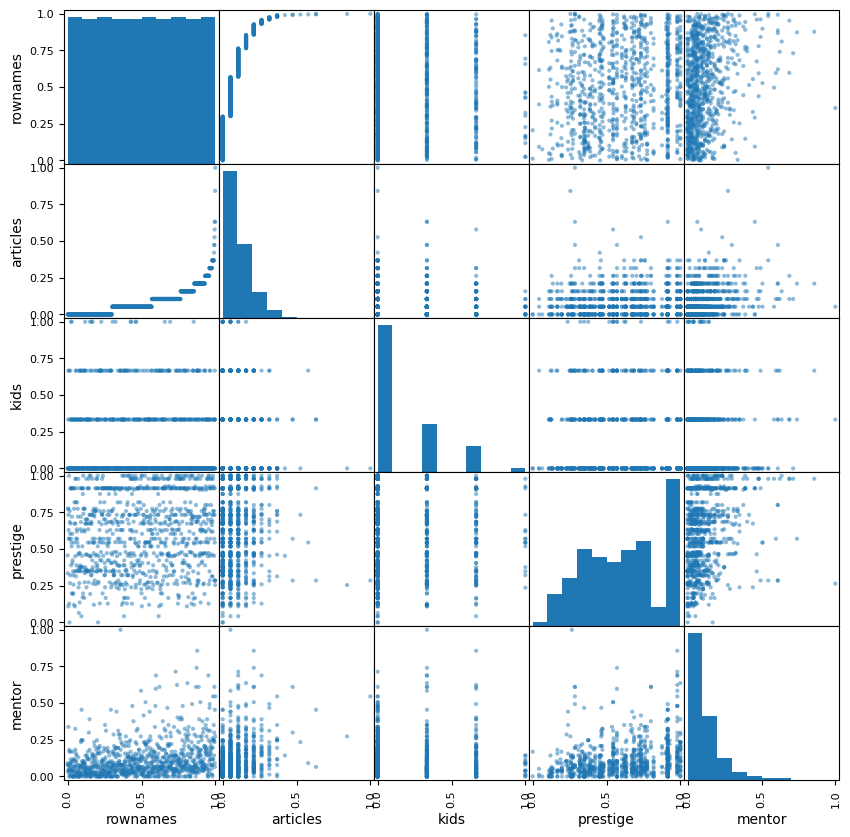

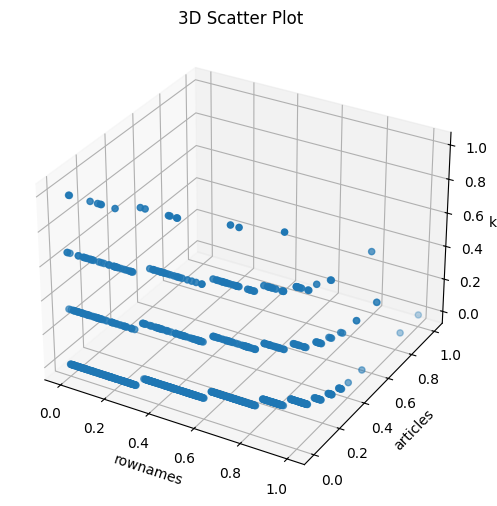

In [9]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()

pd.plotting.scatter_matrix(df[numeric_cols], figsize=(10,10))
plt.show()

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df[numeric_cols[0]], df[numeric_cols[1]], df[numeric_cols[2]])
ax.set_xlabel(numeric_cols[0]); ax.set_ylabel(numeric_cols[1]); ax.set_zlabel(numeric_cols[2])
plt.title("3D Scatter Plot")
plt.show()

---

***PROJECT SUBMISSION - 2***


---



1 . ***1D ANALYSIS***

========== 1D STATISTICAL ANALYSIS ==========

--- rownames ---
Mean: 0.5
Median: 0.5
Mode: 0.0
Variance: 0.08360705581544564
Standard Deviation: 0.2891488471625741
Minimum: 0.0
Maximum: 1.0
Range: 1.0
Q1: 0.25
Q3: 0.75
IQR: 0.5
Skewness: 0.0
Kurtosis: -1.2000000000000004

--- articles ---
Mean: 0.08909979867702042
Median: 0.05263157894736842
Mode: 0.0
Variance: 0.010276292529069489
Standard Deviation: 0.10137205003880255
Minimum: 0.0
Maximum: 1.0
Range: 1.0
Q1: 0.0
Q3: 0.10526315789473684
IQR: 0.10526315789473684
Skewness: 2.52305853238113
Kurtosis: 12.738989288038495

--- kids ---
Mean: 0.1650273224043716
Median: 0.0
Mode: 0.0
Variance: 0.06500460355609673
Standard Deviation: 0.2549600038360855
Minimum: 0.0
Maximum: 1.0
Range: 1.0
Q1: 0.0
Q3: 0.3333333333333333
IQR: 0.3333333333333333
Skewness: 1.3765072553468667
Kurtosis: 0.9064603174756245

--- prestige ---
Mean: 0.6075315228555813
Median: 0.6196636916160152
Mode: 0.9146183873039914
Variance: 0.06485016135673125
Standard Deviation:

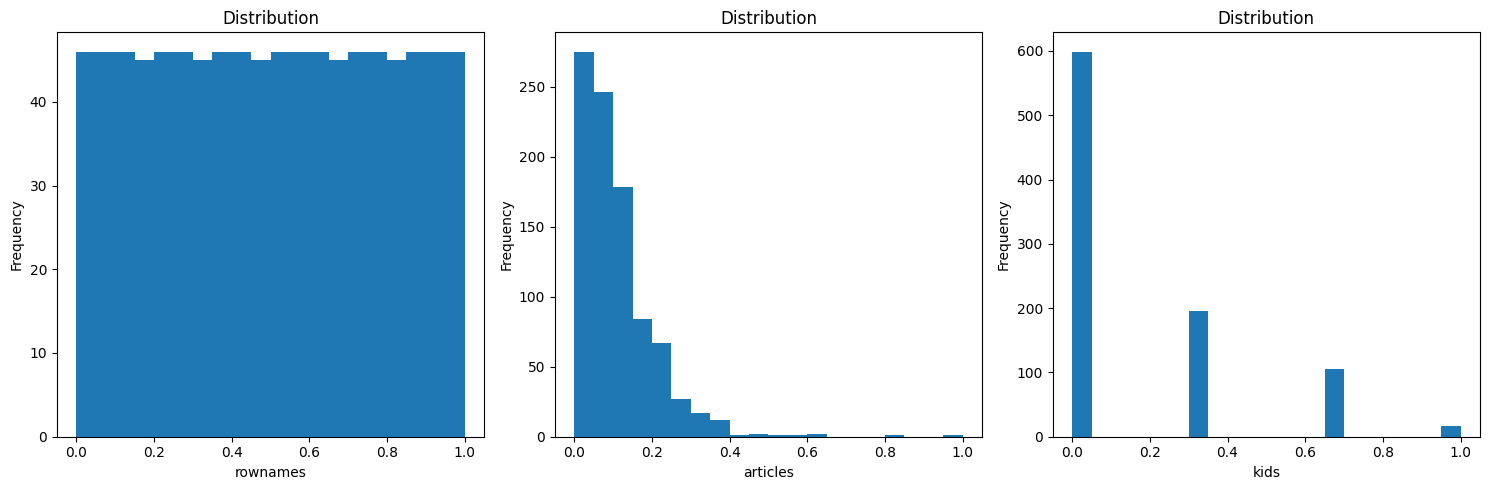

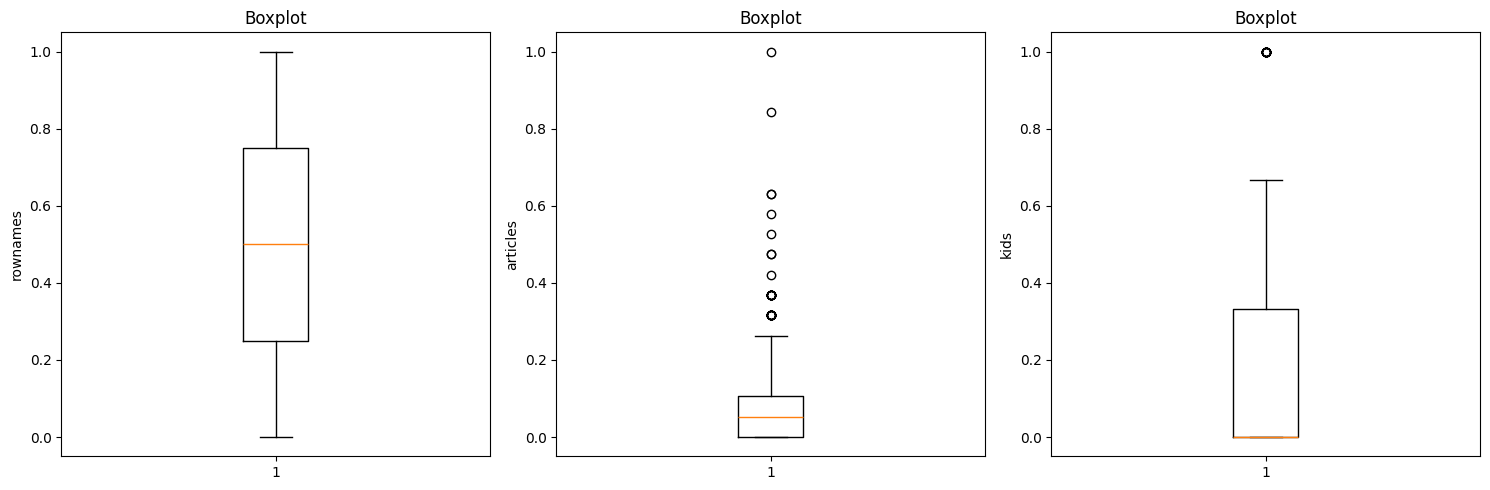

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

numeric_cols = df.select_dtypes(include=np.number).columns

print("========== 1D STATISTICAL ANALYSIS ==========")

for col in numeric_cols:
    print(f"\n--- {col} ---")
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])
    print("Variance:", df[col].var())
    print("Standard Deviation:", df[col].std())
    print("Minimum:", df[col].min())
    print("Maximum:", df[col].max())
    print("Range:", df[col].max() - df[col].min())
    print("Q1:", df[col].quantile(0.25))
    print("Q3:", df[col].quantile(0.75))
    print("IQR:", df[col].quantile(0.75) - df[col].quantile(0.25))
    print("Skewness:", df[col].skew())
    print("Kurtosis:", df[col].kurtosis())

plt.figure(figsize=(15, 5))

for i in range(min(3, len(numeric_cols))):
    plt.subplot(1, 3, i + 1)
    plt.hist(df[numeric_cols[i]], bins=20)
    plt.xlabel(numeric_cols[i])
    plt.ylabel("Frequency")
    plt.title("Distribution")

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))

for i in range(min(3, len(numeric_cols))):
    plt.subplot(1, 3, i + 1)
    plt.boxplot(df[numeric_cols[i]])
    plt.ylabel(numeric_cols[i])
    plt.title("Boxplot")

plt.tight_layout()
plt.show()

2. ***2D STATISTICAL ANALYSIS***

========== 2D STATISTICAL ANALYSIS ==========

--- Covariance Matrix ---


,rownames,articles,kids,prestige,mentor
rownames,0.083607,0.024636,-0.003687,0.008764,0.009881
articles,0.024636,0.010276,-0.001169,0.001893,0.003819
kids,-0.003687,-0.001169,0.065005,-0.001721,0.001163
prestige,0.008764,0.001893,-0.001721,0.064850,0.008168
mentor,0.009881,0.003819,0.001163,0.008168,0.015170



--- Pearson Correlation ---


,rownames,articles,kids,prestige,mentor
rownames,1.000000,0.840483,-0.050011,0.119016,0.277449
articles,0.840483,1.000000,-0.045214,0.073339,0.305862
kids,-0.050011,-0.045214,1.000000,-0.026506,0.037020
prestige,0.119016,0.073339,-0.026506,1.000000,0.260414
mentor,0.277449,0.305862,0.037020,0.260414,1.000000



--- Spearman Correlation ---


,rownames,articles,kids,prestige,mentor
rownames,1.000000,0.972038,-0.037064,0.119469,0.294834
articles,0.972038,1.000000,-0.039288,0.110526,0.302337
kids,-0.037064,-0.039288,1.000000,-0.035075,0.007681
prestige,0.119469,0.110526,-0.035075,1.000000,0.307475
mentor,0.294834,0.302337,0.007681,0.307475,1.000000


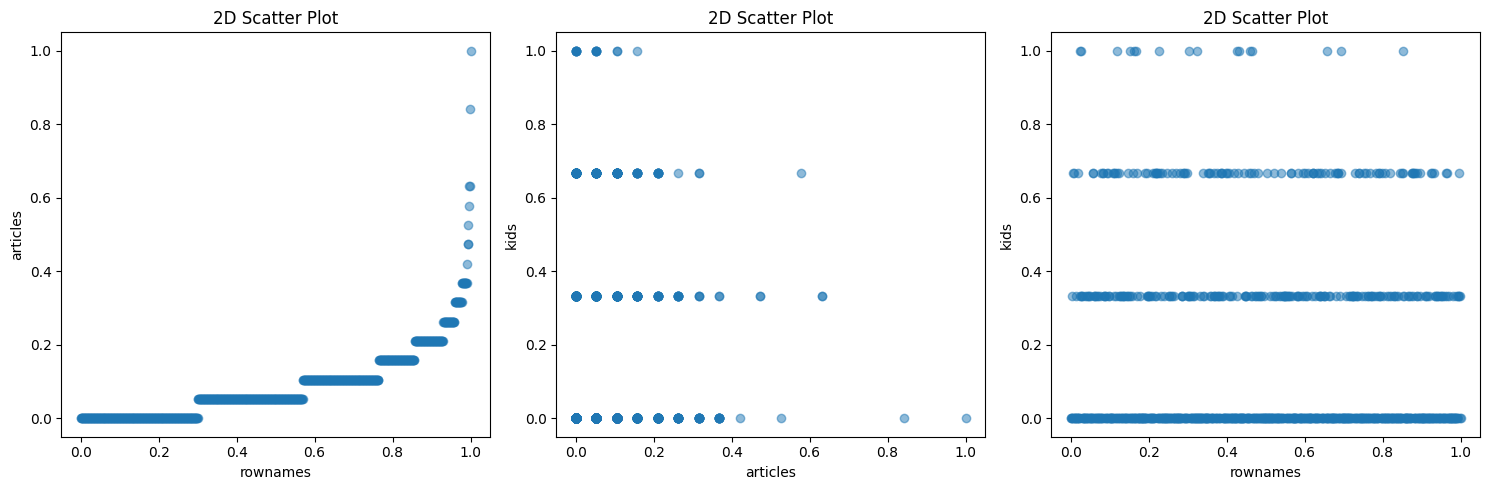

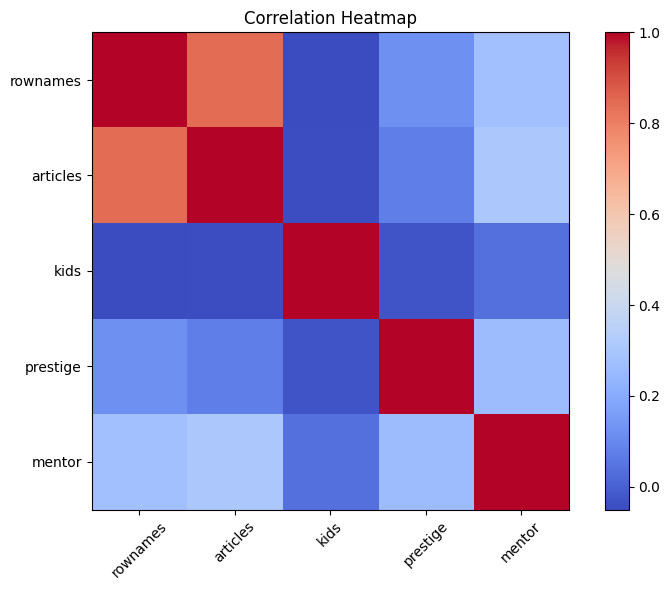

In [11]:
numeric_cols = df.select_dtypes(include=np.number).columns

print("========== 2D STATISTICAL ANALYSIS ==========")

print("\n--- Covariance Matrix ---")
display(df[numeric_cols].cov())

print("\n--- Pearson Correlation ---")
display(df[numeric_cols].corr(method='pearson'))

print("\n--- Spearman Correlation ---")
display(df[numeric_cols].corr(method='spearman'))

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(df[numeric_cols[0]], df[numeric_cols[1]], alpha=0.5)
plt.xlabel(numeric_cols[0])
plt.ylabel(numeric_cols[1])
plt.title("2D Scatter Plot")

plt.subplot(1, 3, 2)
plt.scatter(df[numeric_cols[1]], df[numeric_cols[2]], alpha=0.5)
plt.xlabel(numeric_cols[1])
plt.ylabel(numeric_cols[2])
plt.title("2D Scatter Plot")

plt.subplot(1, 3, 3)
plt.scatter(df[numeric_cols[0]], df[numeric_cols[2]], alpha=0.5)
plt.xlabel(numeric_cols[0])
plt.ylabel(numeric_cols[2])
plt.title("2D Scatter Plot")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.imshow(df[numeric_cols].corr(), cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

3. ***3D STATISTICAL ANALYSIS***

========== 3D STATISTICAL ANALYSIS ==========

--- Statistical Summary ---


,rownames,articles,kids
count,915.000000,915.000000,915.000000
mean,0.500000,0.089100,0.165027
std,0.289149,0.101372,0.254960
min,0.000000,0.000000,0.000000
25%,0.250000,0.000000,0.000000
50%,0.500000,0.052632,0.000000
75%,0.750000,0.105263,0.333333
max,1.000000,1.000000,1.000000



--- Covariance Matrix ---


,rownames,articles,kids
rownames,0.083607,0.024636,-0.003687
articles,0.024636,0.010276,-0.001169
kids,-0.003687,-0.001169,0.065005



--- Correlation Matrix ---


,rownames,articles,kids
rownames,1.000000,0.840483,-0.050011
articles,0.840483,1.000000,-0.045214
kids,-0.050011,-0.045214,1.000000


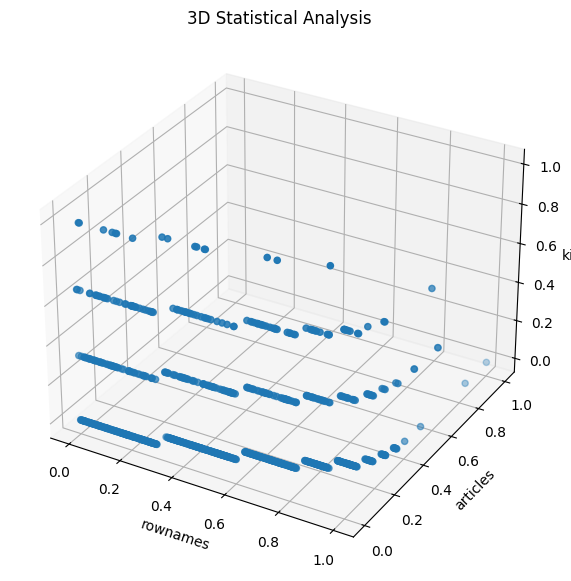

In [12]:
from mpl_toolkits.mplot3d import Axes3D

numeric_cols = df.select_dtypes(include=np.number).columns

print("========== 3D STATISTICAL ANALYSIS ==========")

print("\n--- Statistical Summary ---")
display(df[numeric_cols[:3]].describe())

print("\n--- Covariance Matrix ---")
display(df[numeric_cols[:3]].cov())

print("\n--- Correlation Matrix ---")
display(df[numeric_cols[:3]].corr())

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df[numeric_cols[0]],
    df[numeric_cols[1]],
    df[numeric_cols[2]]
)

ax.set_xlabel(numeric_cols[0])
ax.set_ylabel(numeric_cols[1])
ax.set_zlabel(numeric_cols[2])
ax.set_title("3D Statistical Analysis")

plt.show()

4. ***K-MEANS CLUSTERING***

========== K-MEANS CLUSTERING ==========


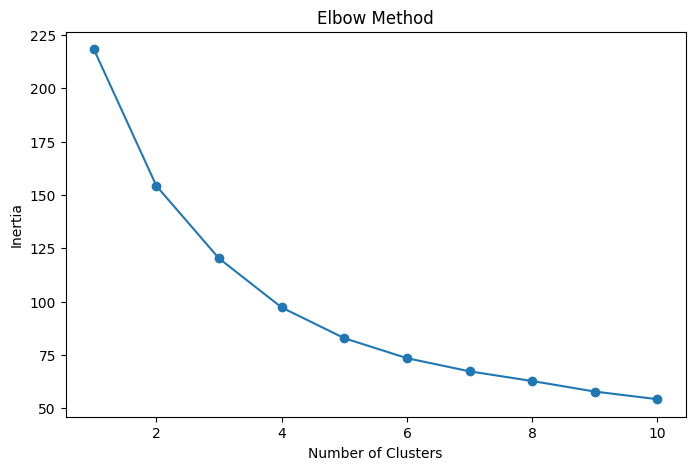


--- Cluster Counts ---
KMeans_Cluster
2    378
0    351
1    186
Name: count, dtype: int64

--- Cluster Centroids ---


,rownames,articles,kids,prestige,mentor
0,0.239131,0.019139,0.058712,0.525664,0.075745
1,0.475096,0.070839,0.580180,0.601112,0.121025
2,0.755114,0.163186,0.060847,0.686910,0.145846



Silhouette Score: 0.29439253560092227


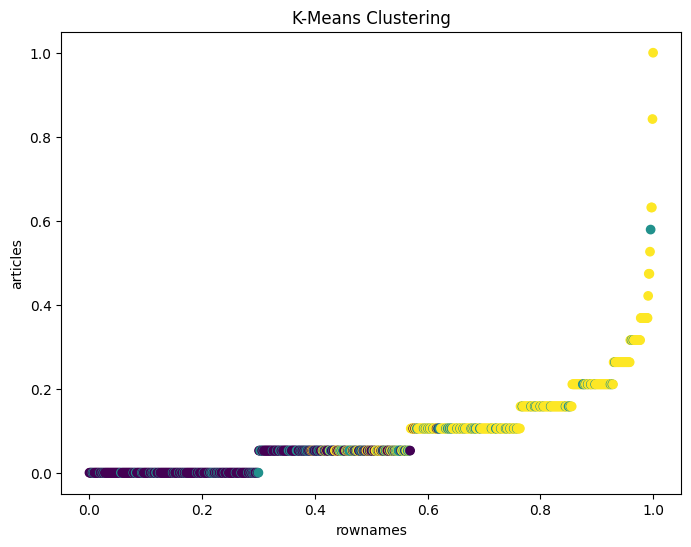

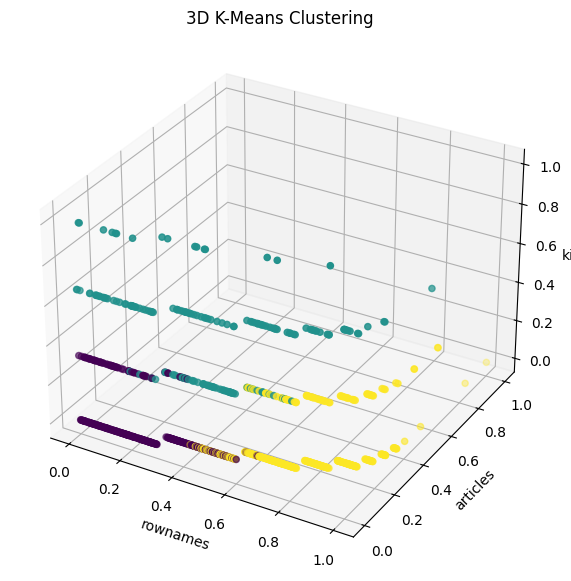

In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

numeric_cols = df.select_dtypes(include=np.number).columns
X = df[numeric_cols].copy()

print("========== K-MEANS CLUSTERING ==========")

# Elbow Method
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# K-Means
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X)

print("\n--- Cluster Counts ---")
print(df['KMeans_Cluster'].value_counts())

print("\n--- Cluster Centroids ---")
display(pd.DataFrame(kmeans.cluster_centers_, columns=numeric_cols))

# Silhouette Score
score = silhouette_score(X, df['KMeans_Cluster'])
print("\nSilhouette Score:", score)

# 2D Visualization
plt.figure(figsize=(8, 6))

plt.scatter(
    df[numeric_cols[0]],
    df[numeric_cols[1]],
    c=df['KMeans_Cluster']
)

plt.xlabel(numeric_cols[0])
plt.ylabel(numeric_cols[1])
plt.title("K-Means Clustering")
plt.show()

# 3D Visualization
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df[numeric_cols[0]],
    df[numeric_cols[1]],
    df[numeric_cols[2]],
    c=df['KMeans_Cluster']
)

ax.set_xlabel(numeric_cols[0])
ax.set_ylabel(numeric_cols[1])
ax.set_zlabel(numeric_cols[2])
ax.set_title("3D K-Means Clustering")

plt.show()

5. ***HIERARCHICAL CLUSTERING***

========== HIERARCHICAL CLUSTERING ==========


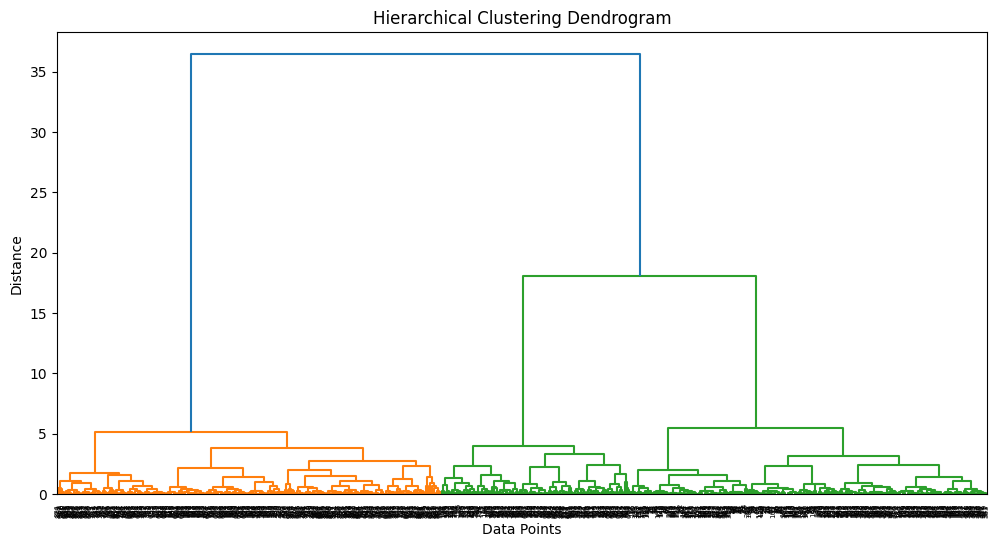


--- Cluster Counts ---
Hierarchical_Cluster
1    378
0    351
2    186
Name: count, dtype: int64

Silhouette Score: 0.6290783392975429


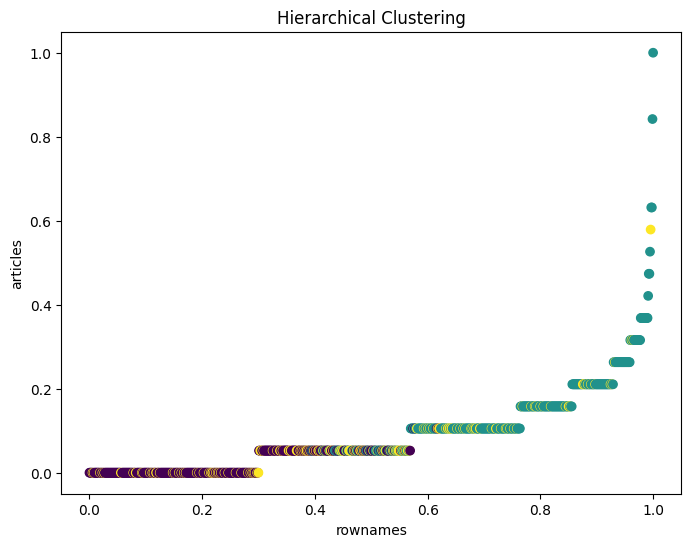

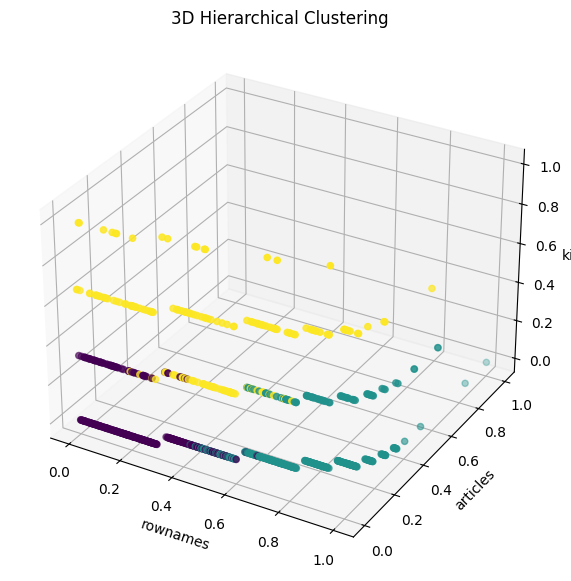

In [14]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

numeric_cols = df.select_dtypes(include=np.number).columns
X = df[numeric_cols].copy()

print("========== HIERARCHICAL CLUSTERING ==========")

# Dendrogram
linked = linkage(X, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

# Hierarchical Clustering
hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage='ward'
)

df['Hierarchical_Cluster'] = hierarchical.fit_predict(X)

print("\n--- Cluster Counts ---")
print(df['Hierarchical_Cluster'].value_counts())

# Silhouette Score
score = silhouette_score(X, df['Hierarchical_Cluster'])
print("\nSilhouette Score:", score)

# 2D Visualization
plt.figure(figsize=(8, 6))

plt.scatter(
    df[numeric_cols[0]],
    df[numeric_cols[1]],
    c=df['Hierarchical_Cluster']
)

plt.xlabel(numeric_cols[0])
plt.ylabel(numeric_cols[1])
plt.title("Hierarchical Clustering")
plt.show()

# 3D Visualization
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df[numeric_cols[0]],
    df[numeric_cols[1]],
    df[numeric_cols[2]],
    c=df['Hierarchical_Cluster']
)

ax.set_xlabel(numeric_cols[0])
ax.set_ylabel(numeric_cols[1])
ax.set_zlabel(numeric_cols[2])
ax.set_title("3D Hierarchical Clustering")

plt.show()